# Supply Chain Analytics Project
**Author:** Kingsley Merafhe  
**Dataset:** Supply Chain Data (100 SKUs across 5 Indian cities)  
**Goal:** Analyse supply chain performance, identify inefficiencies, and predict shipment inspection outcomes.

## Step 1 — Install & Import Libraries

In [1]:
!pip install xgboost plotly --quiet
print("✅ Done")

✅ Done


In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
)
import joblib

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

print("  libraries imported")

✅ All libraries imported


## Step 2 — Business Understanding

**Problem:** Supply chain inefficiencies lead to high defect rates, delays, and revenue loss.  
**Objective:** Analyse product, shipping, and supplier data to uncover bottlenecks and predict inspection failures.  
**Stakeholders:** Supply Chain Managers, Operations Teams, Procurement.  
**Benefits:** Reduce defects, optimise routes, lower shipping costs, improve supplier performance.

## Step 3 — Load Dataset

In [3]:
from google.colab import files
import io

uploaded = files.upload()

df = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))
print("Shape:", df.shape)
df.head()

Saving supply_chain_data.csv to supply_chain_data.csv
Shape: (100, 24)


,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,Shipping times,Shipping carriers,Shipping costs,Supplier name,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.81,55,802,8662.00,Non-binary,58,7,96,4,Carrier B,2.96,Supplier 3,Mumbai,29,215,29,46.28,Pending,0.23,Road,Route B,187.75
1,skincare,SKU1,14.84,95,736,7460.90,Female,53,30,37,2,Carrier A,9.72,Supplier 3,Mumbai,23,517,30,33.62,Pending,4.85,Road,Route B,503.07
2,haircare,SKU2,11.32,34,8,9577.75,Unknown,1,10,88,2,Carrier B,8.05,Supplier 1,Mumbai,12,971,27,30.69,Pending,4.58,Air,Route C,141.92
3,skincare,SKU3,61.16,68,83,7766.84,Non-binary,23,13,59,6,Carrier C,1.73,Supplier 5,Kolkata,24,937,18,35.62,Fail,4.75,Rail,Route A,254.78
4,skincare,SKU4,4.81,26,871,2686.51,Non-binary,5,3,56,8,Carrier A,3.89,Supplier 1,Delhi,5,414,3,92.07,Fail,3.15,Air,Route A,923.44


## Step 4 — Data Understanding

In [4]:
# Column types
print(df.dtypes)

Product type                object
SKU                         object
Price                      float64
Availability                 int64
Number of products sold      int64
Revenue generated          float64
Customer demographics       object
Stock levels                 int64
Lead times                   int64
Order quantities             int64
Shipping times               int64
Shipping carriers           object
Shipping costs             float64
Supplier name               object
Location                    object
Lead time                    int64
Production volumes           int64
Manufacturing lead time      int64
Manufacturing costs        float64
Inspection results          object
Defect rates               float64
Transportation modes        object
Routes                      object
Costs                      float64
dtype: object


In [5]:
# Statistical summary
df.describe()

,Price,Availability,Number of products sold,Revenue generated,Stock levels,Lead times,Order quantities,Shipping times,Shipping costs,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Defect rates,Costs
count,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
mean,49.46,48.40,460.99,5776.05,47.77,15.96,49.22,5.75,5.55,17.08,567.84,14.77,47.27,2.28,529.25
std,31.17,30.74,303.78,2732.84,31.37,8.79,26.78,2.72,2.65,8.85,263.05,8.91,28.98,1.46,258.30
min,1.70,1.00,8.00,1061.62,0.00,1.00,1.00,1.00,1.01,1.00,104.00,1.00,1.09,0.02,103.92
25%,19.60,22.75,184.25,2812.85,16.75,8.00,26.00,3.75,3.54,10.00,352.00,7.00,22.98,1.01,318.78
50%,51.24,43.50,392.50,6006.35,47.50,17.00,52.00,6.00,5.32,18.00,568.50,14.00,45.91,2.14,520.43
75%,77.20,75.00,704.25,8253.98,73.00,24.00,71.25,8.00,7.60,25.00,797.00,23.00,68.62,3.56,763.08
max,99.17,100.00,996.00,9866.47,100.00,30.00,96.00,10.00,9.93,30.00,985.00,30.00,99.47,4.94,997.41


In [6]:
# Missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values per column:
Product type               0
SKU                        0
Price                      0
Availability               0
Number of products sold    0
Revenue generated          0
Customer demographics      0
Stock levels               0
Lead times                 0
Order quantities           0
Shipping times             0
Shipping carriers          0
Shipping costs             0
Supplier name              0
Location                   0
Lead time                  0
Production volumes         0
Manufacturing lead time    0
Manufacturing costs        0
Inspection results         0
Defect rates               0
Transportation modes       0
Routes                     0
Costs                      0
dtype: int64

Total missing: 0


In [7]:
# Categorical value counts
cat_cols = ["Product type", "Inspection results", "Transportation modes",
            "Routes", "Location", "Shipping carriers"]

for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


Product type:
Product type
skincare     40
haircare     34
cosmetics    26
Name: count, dtype: int64

Inspection results:
Inspection results
Pending    41
Fail       36
Pass       23
Name: count, dtype: int64

Transportation modes:
Transportation modes
Road    29
Rail    28
Air     26
Sea     17
Name: count, dtype: int64

Routes:
Routes
Route A    43
Route B    37
Route C    20
Name: count, dtype: int64

Location:
Location
Kolkata      25
Mumbai       22
Chennai      20
Bangalore    18
Delhi        15
Name: count, dtype: int64

Shipping carriers:
Shipping carriers
Carrier B    43
Carrier C    29
Carrier A    28
Name: count, dtype: int64


## Step 5 — Data Cleaning & Feature Engineering

In [8]:
# Check duplicates
print(f"Duplicates: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Shape after dedup: {df.shape}")

Duplicates: 0
Shape after dedup: (100, 24)


In [9]:
# Create target variable — is_delayed (1 = shipping time above median)
median_shipping = df["Shipping times"].median()
df["is_delayed"] = (df["Shipping times"] > median_shipping).astype(int)
print(f"Median shipping time: {median_shipping} days")
print(df["is_delayed"].value_counts())

Median shipping time: 6.0 days
is_delayed
0    53
1    47
Name: count, dtype: int64


In [10]:
# Create high defect flag
df["high_defect"] = (df["Defect rates"] > df["Defect rates"].median()).astype(int)

# Profit margin estimate
df["profit_margin"] = df["Revenue generated"] - df["Costs"] - df["Manufacturing costs"]

# Cost per unit
df["cost_per_unit"] = df["Costs"] / df["Order quantities"]

print("✅ New features created")
df[["is_delayed", "high_defect", "profit_margin", "cost_per_unit"]].describe()

✅ New features created


,is_delayed,high_defect,profit_margin,cost_per_unit
count,100.00,100.00,100.00,100.00
mean,0.47,0.50,5199.54,24.50
std,0.50,0.50,2744.30,52.96
min,0.00,0.00,747.14,1.22
25%,0.00,0.00,2316.72,6.71
50%,0.00,0.50,5365.02,11.57
75%,1.00,1.00,7641.26,16.76
max,1.00,1.00,9405.14,379.36


In [11]:
# Encode categorical columns for ML
le = LabelEncoder()
cat_to_encode = ["Product type", "Transportation modes", "Routes",
                 "Location", "Shipping carriers", "Inspection results"]

df_encoded = df.copy()
for col in cat_to_encode:
    df_encoded[col + "_enc"] = le.fit_transform(df[col])

print("✅ Encoding done")

✅ Encoding done


## Step 6 — Exploratory Data Analysis (EDA)

In [12]:
# KPI Summary
print("=" * 45)
print(f"  Total SKUs          : {len(df)}")
print(f"  Total Revenue       : ${df['Revenue generated'].sum():,.0f}")
print(f"  Avg Defect Rate     : {df['Defect rates'].mean():.2f}%")
print(f"  Avg Shipping Time   : {df['Shipping times'].mean():.1f} days")
print(f"  Avg Shipping Cost   : ${df['Shipping costs'].mean():.2f}")
print(f"  Delayed Shipments   : {df['is_delayed'].sum()} ({df['is_delayed'].mean()*100:.0f}%)")
print("=" * 45)

  Total SKUs          : 100
  Total Revenue       : $577,605
  Avg Defect Rate     : 2.28%
  Avg Shipping Time   : 5.8 days
  Avg Shipping Cost   : $5.55
  Delayed Shipments   : 47 (47%)


In [13]:
# Revenue by product type
fig = px.bar(
    df.groupby("Product type")["Revenue generated"].sum().reset_index(),
    x="Product type", y="Revenue generated", color="Product type",
    title="Total Revenue by Product Type"
)
fig.show()

In [14]:
# Defect rate by transportation mode
fig = px.box(
    df, x="Transportation modes", y="Defect rates",
    color="Transportation modes",
    title="Defect Rates by Transportation Mode"
)
fig.show()

In [15]:
# Shipping cost vs shipping time
fig = px.scatter(
    df, x="Shipping times", y="Shipping costs",
    color="Transportation modes", size="Order quantities",
    hover_data=["SKU", "Routes"],
    title="Shipping Cost vs Shipping Time"
)
fig.show()

In [16]:
# Inspection results distribution
fig = px.pie(
    df, names="Inspection results",
    title="Inspection Results Distribution",
    color_discrete_map={"Pass":"#2ecc71","Fail":"#e74c3c","Pending":"#f39c12"}
)
fig.show()

In [17]:
# Defect rate by location
location_defect = df.groupby("Location")["Defect rates"].mean().reset_index().sort_values("Defect rates", ascending=False)
fig = px.bar(location_defect, x="Location", y="Defect rates",
             color="Defect rates", color_continuous_scale="Reds",
             title="Average Defect Rate by Location")
fig.show()

In [18]:
# Revenue vs costs scatter
fig = px.scatter(
    df, x="Costs", y="Revenue generated",
    color="Product type", size="Number of products sold",
    title="Revenue vs Total Costs by Product Type"
)
fig.show()

In [19]:
# Stock levels by supplier
fig = px.bar(
    df.groupby("Supplier name")["Stock levels"].mean().reset_index(),
    x="Supplier name", y="Stock levels", color="Supplier name",
    title="Average Stock Levels by Supplier"
)
fig.show()

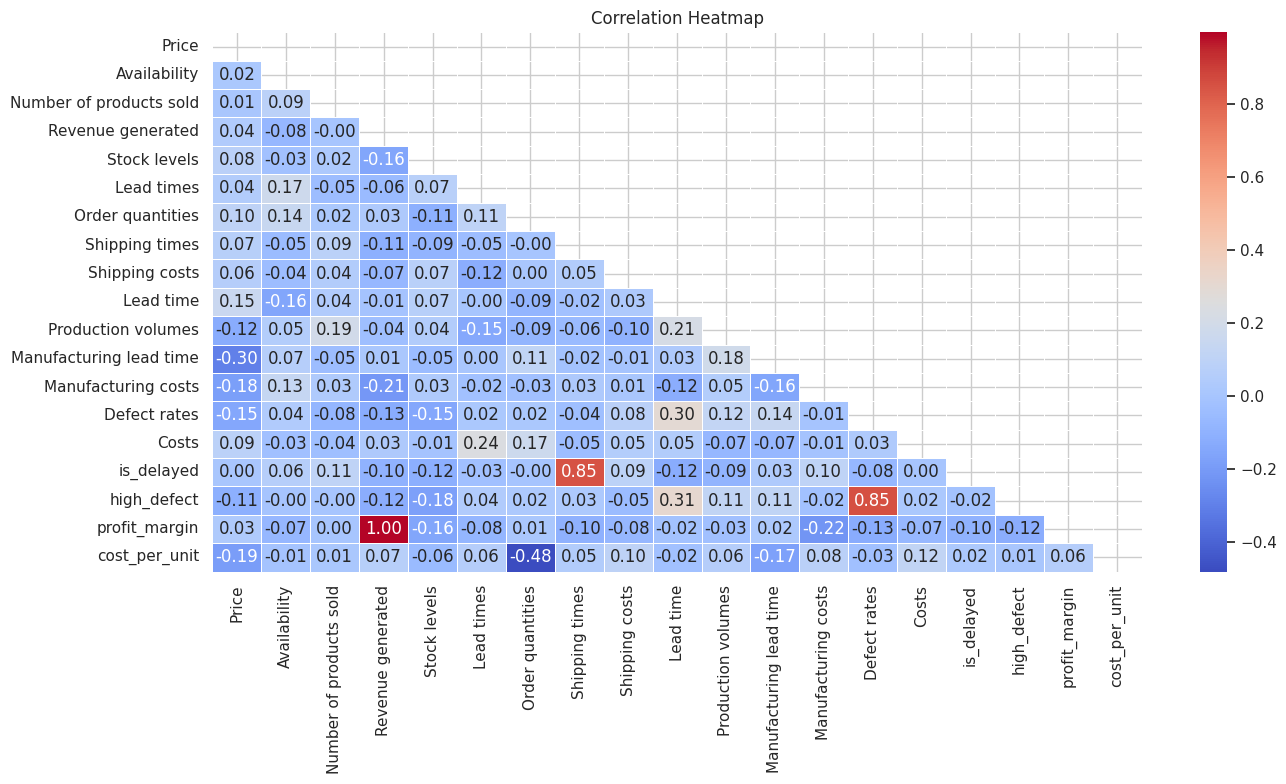

In [20]:
# Correlation heatmap
plt.figure(figsize=(14, 8))
corr = df.select_dtypes(include=np.number).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Step 7 — Machine Learning

**Target:** `is_delayed` — predicts whether a shipment will exceed the median shipping time.  
**Models:** Random Forest, XGBoost, Decision Tree

In [21]:
# Features and target
feature_cols = [
    "Price", "Availability", "Number of products sold",
    "Stock levels", "Lead times", "Order quantities",
    "Shipping costs", "Lead time", "Production volumes",
    "Manufacturing lead time", "Manufacturing costs", "Defect rates",
    "Transportation modes_enc", "Routes_enc", "Location_enc",
    "Shipping carriers_enc", "Product type_enc"
]

X = df_encoded[feature_cols]
y = df_encoded["is_delayed"]

print("Features shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Features shape: (100, 17)
Target distribution:
 is_delayed
0    53
1    47
Name: count, dtype: int64


In [22]:
# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")

Train: 80  |  Test: 20


In [23]:
# Train all three models
models = {
    "Random Forest" : RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost"       : XGBClassifier(eval_metric="logloss", random_state=42),
    "Decision Tree" : DecisionTreeClassifier(max_depth=10, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        "Accuracy" : round(accuracy_score(y_test, preds), 4),
        "Precision": round(precision_score(y_test, preds, zero_division=0), 4),
        "Recall"   : round(recall_score(y_test, preds, zero_division=0), 4),
        "F1 Score" : round(f1_score(y_test, preds, zero_division=0), 4),
    }

pd.DataFrame(results).T

,Accuracy,Precision,Recall,F1 Score
Random Forest,0.60,0.57,0.44,0.50
XGBoost,0.40,0.33,0.33,0.33
Decision Tree,0.45,0.40,0.44,0.42


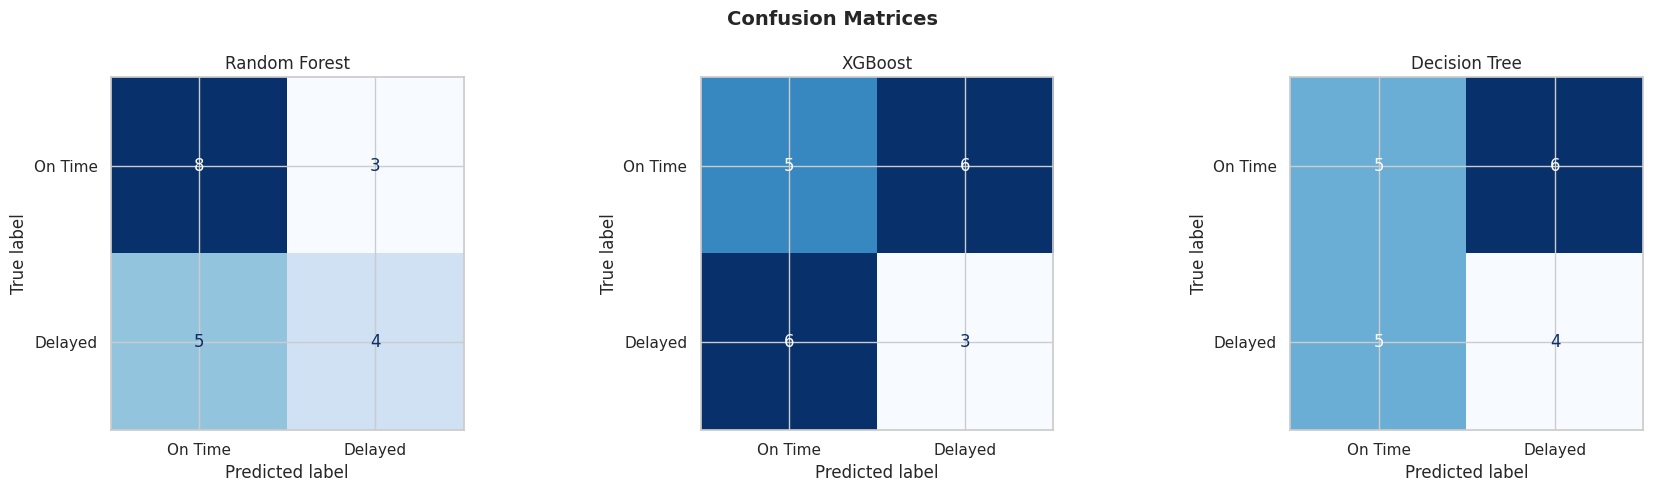

In [24]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, model) in zip(axes, models.items()):
    cm   = confusion_matrix(y_test, model.predict(X_test))
    disp = ConfusionMatrixDisplay(cm, display_labels=["On Time", "Delayed"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
plt.suptitle("Confusion Matrices", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

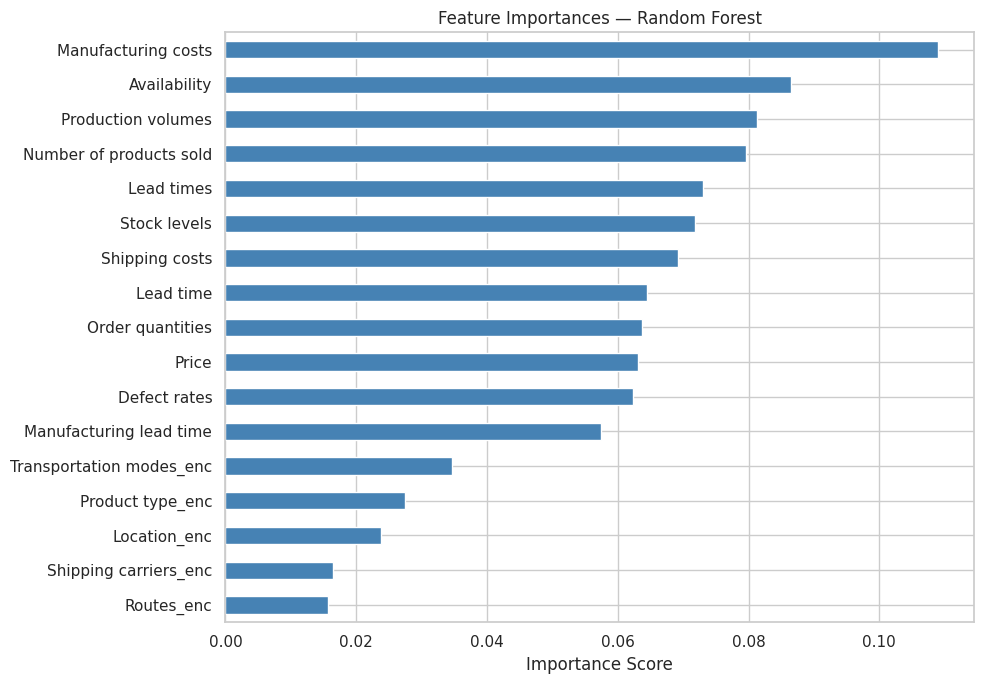

In [25]:
# Feature importance — Random Forest
importance = pd.Series(
    models["Random Forest"].feature_importances_, index=feature_cols
).sort_values(ascending=True)

importance.plot(kind="barh", color="steelblue", figsize=(10, 7))
plt.title("Feature Importances — Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [26]:
# Save best model
os.makedirs("models", exist_ok=True)
joblib.dump(models["Random Forest"], "models/best_model.pkl")
joblib.dump(feature_cols, "models/feature_columns.pkl")
print("✅ Model saved")

✅ Model saved


## Step 8 — Business Insights & Recommendations

In [27]:
# Summary insights
top_defect_location = df.groupby("Location")["Defect rates"].mean().idxmax()
top_revenue_product = df.groupby("Product type")["Revenue generated"].sum().idxmax()
best_route          = df.groupby("Routes")["Shipping costs"].mean().idxmin()
worst_transport     = df.groupby("Transportation modes")["Defect rates"].mean().idxmax()

insights = {
    "Insight": [
        "Delayed shipments",
        "Highest defect location",
        "Top revenue product",
        "Most cost-efficient route",
        "Highest defect transport mode"
    ],
    "Finding": [
        f"{df['is_delayed'].mean()*100:.0f}% of shipments exceed median shipping time",
        top_defect_location,
        top_revenue_product,
        best_route,
        worst_transport
    ]
}
pd.DataFrame(insights)

,Insight,Finding
0,Delayed shipments,47% of shipments exceed median shipping time
1,Highest defect location,Chennai
2,Top revenue product,skincare
3,Most cost-efficient route,Route A
4,Highest defect transport mode,Road


## Step 9 — Recommendations

1. **Route Optimisation** — Prioritise the most cost-efficient route for high-volume orders.  
2. **Supplier Review** — Audit suppliers in high-defect locations to reduce failure rates.  
3. **Transport Mode** — Reduce reliance on the highest-defect transport mode where possible.  
4. **Predictive Alerts** — Deploy the trained model to flag at-risk shipments before dispatch.  
5. **Stock Management** — Restock low-availability SKUs proactively to avoid lost sales.